In [46]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,cross_val_score,KFold,GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import make_regression
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score

In [47]:
X,y = make_regression(
                    n_samples=10000,
                    n_features=5,
                    n_targets=1,
                    noise=0.25,
                    random_state=10,
                    bias = 0.1
)

In [48]:
df = pd.DataFrame(
                    X,
                    columns = [f'feature_{i}' for i in range(X.shape[1])]
)

In [49]:
df['target'] = y

In [50]:
df

,feature_0,feature_1,feature_2,feature_3,feature_4,target
0,0.132859,-0.354963,0.220215,1.685069,-0.271216,118.228469
1,0.462224,-1.494843,-1.791209,-0.604650,-0.447837,-273.630243
2,-0.644977,0.225277,-0.289781,-0.422958,-1.410410,-83.561818
3,0.013977,-2.618917,-0.948404,-0.724742,-0.582413,-364.354990
4,-1.437146,0.016530,0.072146,0.666277,-2.708702,-59.510209
...,...,...,...,...,...,...
9995,0.824889,0.844102,-0.542834,-0.089633,-0.459205,95.974380
9996,-0.871608,0.073655,0.279626,-0.702941,1.044915,-89.504788
9997,0.497698,-0.512008,-0.036750,-1.036820,0.847832,-88.754589
9998,0.591352,0.308048,-0.548141,-1.315422,0.210219,-62.026577


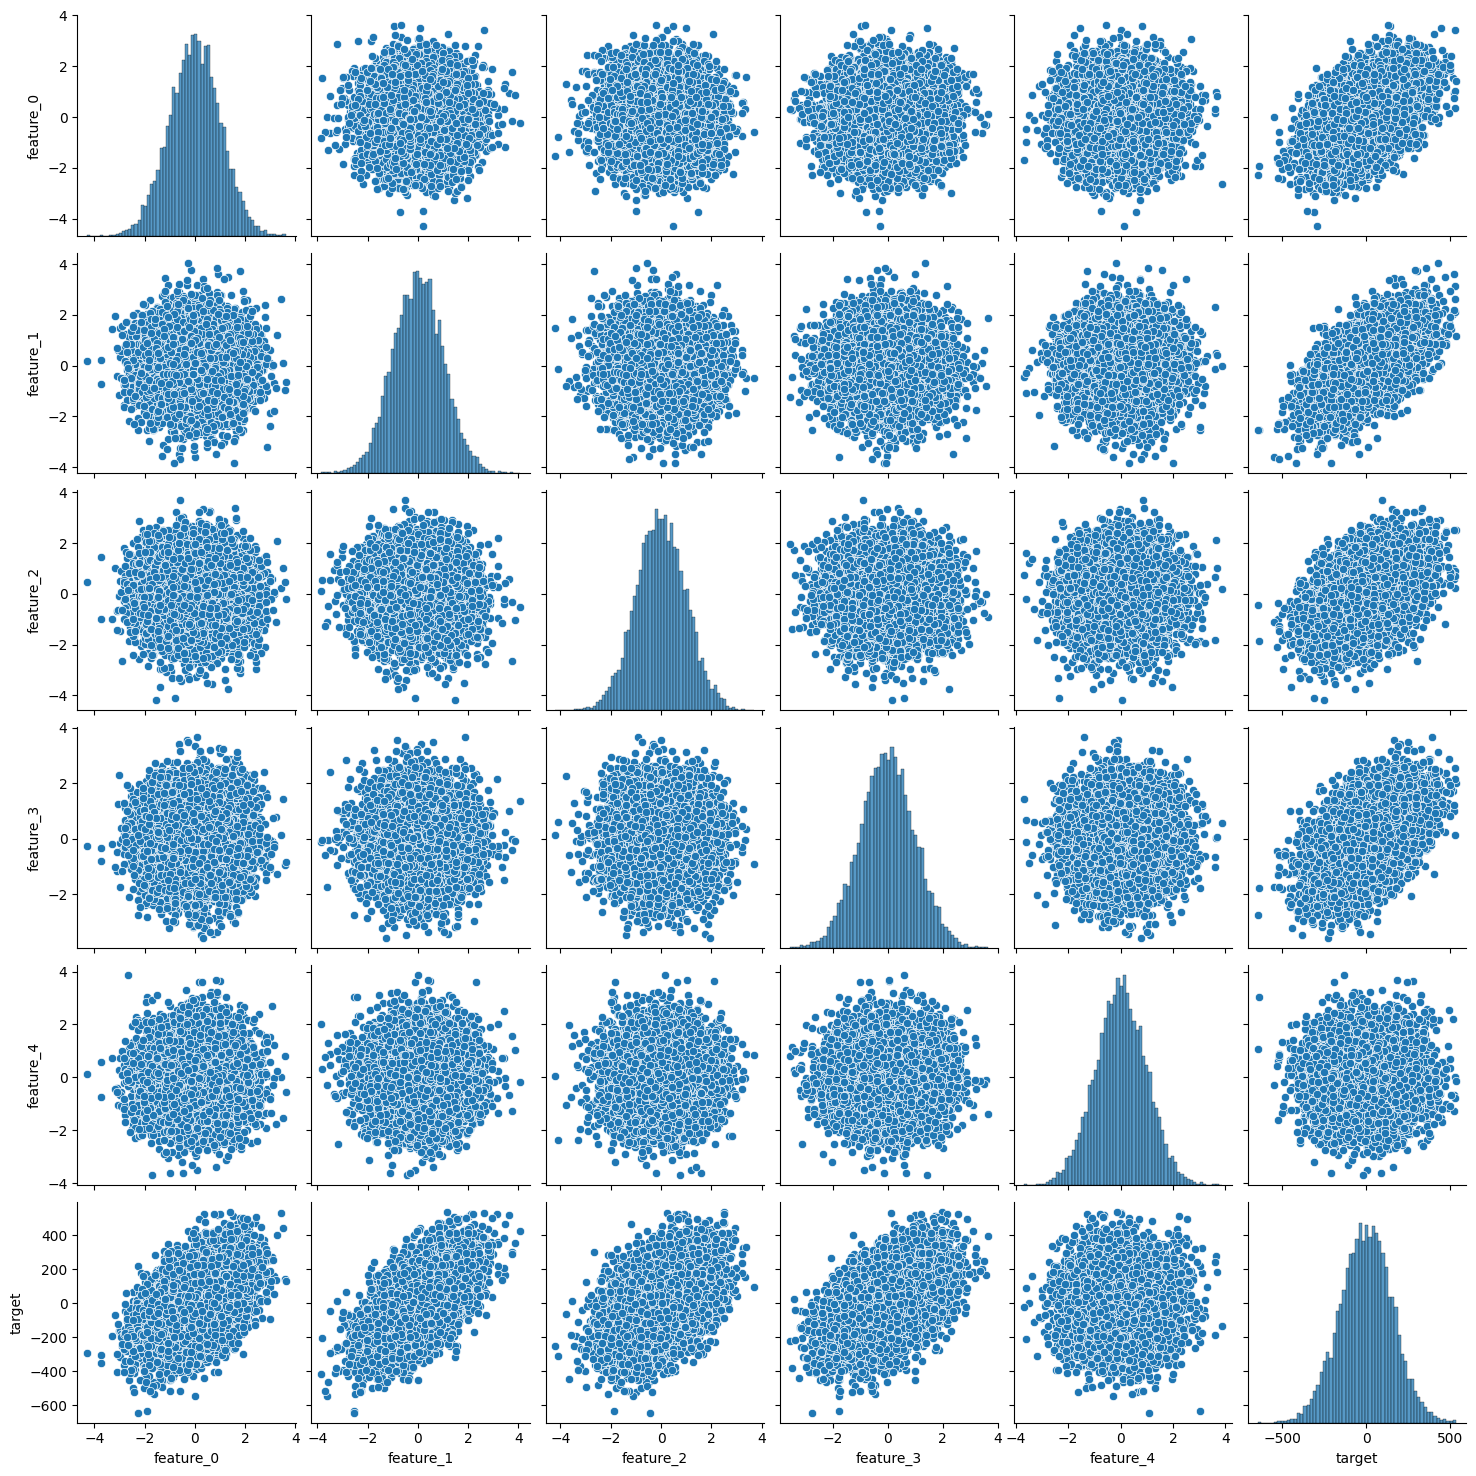

In [51]:
sns.pairplot(
                data = df
)
plt.show()

In [52]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [107]:
gbr = GradientBoostingRegressor(
                                    # n_estimators = 100,
                                    # max_depth = 3,
                                    # learning_rate = 0.1,
                                    # criterion = 'squared_error',  
)

In [108]:
gbr.fit(X_train,y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [109]:
y_pred_gbr = gbr.predict(X_test)

In [110]:
mean_absolute_error(y_test,y_pred_gbr)

11.63621419698607

In [111]:
root_mean_squared_error(y_test,y_pred_gbr)

15.228842452959436

In [112]:
r2_score(y_test,y_pred_gbr)

0.990167402880165

In [ ]:
cvs = cross_val_score(
                        gbr,
                        X,
                        y,
                        cv = 10
)

In [ ]:
cvs.mean(),cvs.std()

(np.float64(0.9904072976484439), np.float64(0.000713838670556126))